# Hero FinCorp – Comprehensive Data-Driven Analysis


## Import Libraries & Load Datasets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#plot
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

#Load the datasets
customers     = pd.read_csv('customers.csv')
applications  = pd.read_csv('applications.csv')
branches      = pd.read_csv('branches.csv')
defaults      = pd.read_csv('defaults.csv')
loans         = pd.read_csv('loans.csv')
transactions  = pd.read_csv('transactions.csv')

#Check the loaded datasets
print("Datasets loaded successfully!")
print(f"  customers:    {customers.shape}")
print(f"  applications: {applications.shape}")
print(f"  branches:     {branches.shape}")
print(f"  defaults:     {defaults.shape}")
print(f"  loans:        {loans.shape}")
print(f"  transactions: {transactions.shape}")


Datasets loaded successfully!
  customers:    (70000, 14)
  applications: (82600, 10)
  branches:     (50, 9)
  defaults:     (9000, 9)
  loans:        (90000, 12)
  transactions: (495000, 9)


---
## Task 1 :Data Quality & Preparation

In [4]:
# Understand the datasets
datasets = {
    'customers':    customers,
    'applications': applications,
    'branches':     branches,
    'defaults':     defaults,
    'loans':        loans,
    'transactions': transactions
}


for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"  {name.upper()}  |  rows: {df.shape[0]}  cols: {df.shape[1]}")
    print(f"{'='*50}")
    print(df.dtypes)



  CUSTOMERS  |  rows: 70000  cols: 14
Customer_ID                object
Full_Name                  object
Contact_Number              int64
Email                      object
Address                    object
Age                         int64
Gender                     object
Marital_Status             object
Employment_Status          object
Annual_Income               int64
Credit_Score                int64
Region                     object
Account_Tenure             object
Relationship_Manager_ID    object
dtype: object

  APPLICATIONS  |  rows: 82600  cols: 10
Application_ID      object
Loan_ID             object
Customer_ID         object
Application_Date    object
Approval_Date       object
Loan_Purpose        object
Source_Channel      object
Processing_Fee       int64
Approval_Status     object
Rejection_Reason    object
dtype: object

  BRANCHES  |  rows: 50  cols: 9
Branch_ID                     object
Branch_Name                   object
Region                        object


In [5]:
#Check missing values
print("MISSING VALUES PER COLUMN")

for name, df in datasets.items():
    print("---", name, "---")
    
    # Get the sum of nulls for each column
    missing_counts = df.isnull().sum()
    
    # Go through each column one by one
    for column_name, count in missing_counts.items():
        # Only print if the count is more than zero
        if count > 0:
            print(column_name, ":", count)
    
    print("") # Just a blank line for space


MISSING VALUES PER COLUMN
--- customers ---

--- applications ---
Loan_ID : 12600
Approval_Date : 12600
Rejection_Reason : 70000

--- branches ---

--- defaults ---
Recovery_Status : 2985

--- loans ---
Collateral_Details : 30194

--- transactions ---



In [6]:
#Handle missing values

customers['Credit_Score'].fillna(customers['Credit_Score'].median(), inplace=True)
customers['Annual_Income'].fillna(customers['Annual_Income'].median(), inplace=True)

applications['Rejection_Reason'].fillna('Not Rejected', inplace=True)

defaults.fillna(0, inplace=True)
transactions.fillna(0, inplace=True)

print("Missing values were handled.")


Missing values were handled.


In [7]:
# Removing the duplicate rows 
for name in list(datasets.keys()):
    before = datasets[name].shape[0]
    datasets[name] = datasets[name].drop_duplicates()
    after  = datasets[name].shape[0]
    print(f"{name}: removed {before - after} duplicates")



customers: removed 0 duplicates
applications: removed 0 duplicates
branches: removed 0 duplicates
defaults: removed 0 duplicates
loans: removed 0 duplicates
transactions: removed 0 duplicates


In [8]:

customers = datasets['customers']
applications = datasets['applications']
branches = datasets['branches']
defaults = datasets['defaults']
loans = datasets['loans']
transactions = datasets['transactions']


In [9]:
# Standardize date formats
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])
applications['Approval_Date']    = pd.to_datetime(applications['Approval_Date'], errors='coerce')
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])
defaults['Default_Date']         = pd.to_datetime(defaults['Default_Date'])
loans['Disbursal_Date']          = pd.to_datetime(loans['Disbursal_Date'],          errors='coerce')
loans['Repayment_Start_Date']    = pd.to_datetime(loans['Repayment_Start_Date'],    errors='coerce')
loans['Repayment_End_Date']      = pd.to_datetime(loans['Repayment_End_Date'],      errors='coerce')

print("Date columns converted to datetime.")


Date columns converted to datetime.


In [10]:
# 
#TO find the middle range or the inter quartile range for Loan Amount
q1 = loans['Loan_Amount'].quantile(0.25)
q3 = loans['Loan_Amount'].quantile(0.75)
iqr = q3 - q1

# defining the 
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# removing outliers
loans = loans[(loans['Loan_Amount'] >= lower_bound) & (loans['Loan_Amount'] <= upper_bound)]

#Outliers for interest rate removed
q1_rate = loans['Interest_Rate'].quantile(0.25)
q3_rate = loans['Interest_Rate'].quantile(0.75)
iqr_rate = q3_rate - q1_rate
loans = loans[(loans['Interest_Rate'] >= q1_rate - 1.5 * iqr_rate) & (loans['Interest_Rate'] <= q3_rate + 1.5 * iqr_rate)]

loans.shape


(90000, 12)

---
## Task 2: Descriptive Analysis

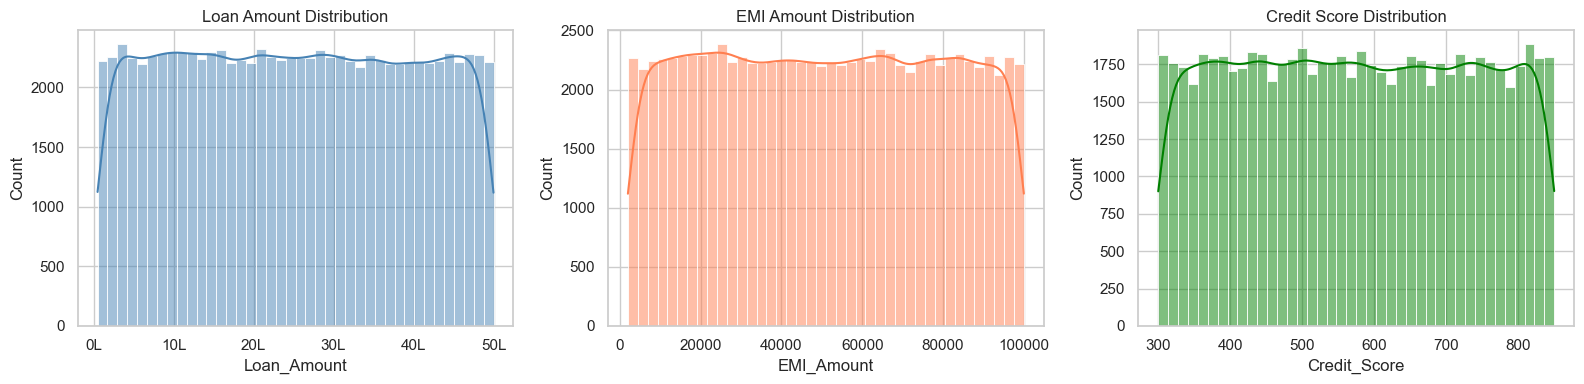

In [11]:
#Distribution plot to see the Loan_Amount, EMI_Amount, Credit_Score columns
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(loans['Loan_Amount'],    bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Loan Amount Distribution')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

sns.histplot(loans['EMI_Amount'],     bins=40, kde=True, ax=axes[1], color='coral')
axes[1].set_title('EMI Amount Distribution')

sns.histplot(customers['Credit_Score'], bins=40, kde=True, ax=axes[2], color='green')
axes[2].set_title('Credit Score Distribution')

plt.tight_layout()
plt.show()


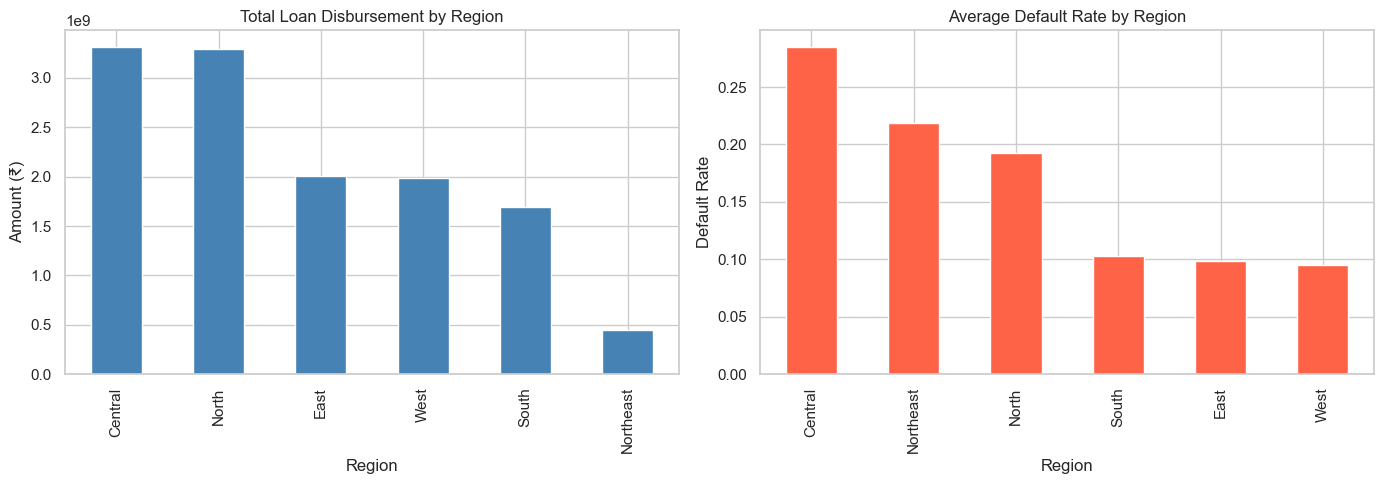

In [12]:
#Checking the Regional trends for load disbursment and defaults
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_disbursement = branches.groupby('Region')['Loan_Disbursement_Amount'].sum().sort_values(ascending=False)
region_disbursement.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Loan Disbursement by Region')
axes[0].set_ylabel('Amount (₹)')
axes[0].set_xlabel('Region')
axes[0].tick_params(axis='x')

branches['Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']
region_default = branches.groupby('Region')['Default_Rate'].mean().sort_values(ascending=False)
region_default.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Average Default Rate by Region')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('Region')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()


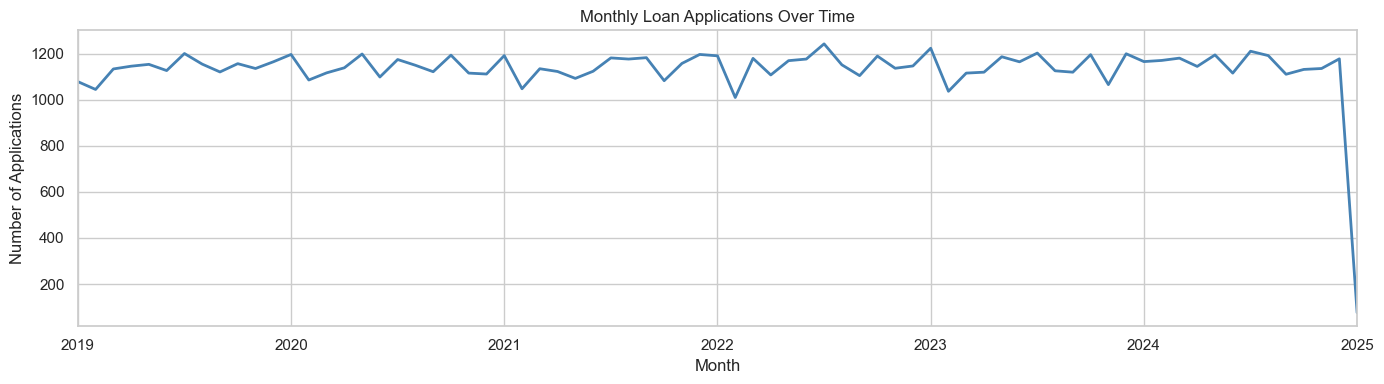

In [13]:
#Monthly loan applications throught the years
applications['Month'] = applications['Application_Date'].dt.to_period('M')
monthly_apps = applications.groupby('Month').size()

plt.figure(figsize=(14, 4))
monthly_apps.plot(color='steelblue', linewidth=2)
plt.title('Monthly Loan Applications Over Time')
plt.ylabel('Number of Applications')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


---
## Task 3: Default Risk Analysis

In [14]:
# Merge into a datset that can be use for all analysis
loan_default = loans.merge(defaults[['Loan_ID','Default_ID','Default_Amount',
                                      'Recovery_Amount','Default_Reason',
                                      'Recovery_Status','Legal_Action']],
                           on='Loan_ID', how='left')

loan_default['Default_Flag'] = loan_default['Default_ID'].notnull().astype(int)

#Inlcude customer info as well
loan_customer = loan_default.merge(customers[['Customer_ID','Credit_Score',
                                               'Annual_Income','Employment_Status',
                                               'Age','Gender','Region']],
                                   on='Customer_ID', how='left')

print(f"loan_customer shape: {loan_customer.shape}")
print(f"Total defaults in merged data: {loan_customer['Default_Flag'].sum()}")


loan_customer shape: (90461, 25)
Total defaults in merged data: 9000


In [15]:
#Most imp thing- make the merged dataset that will be used futher
#Doing various steps
#Create a subset first then merge
#defaults_subset = defaults[['Loan_ID','Default_ID','Default_Amount', 'Recovery_Amount']]

# Merge loans and  new subset
#loan_default = pd.merge(loans, defaults_subset, on='Loan_ID', how='left')
#loan_default['Default_Flag'] = 0
#loan_default.loc[loan_default['Default_ID'].notnull(), 'Default_Flag'] = 1

#merge with customer information
#customer_subset = customers[['Customer_ID', 'Credit_Score', 'Annual_Income', 'Age']]
#final_data = pd.merge(loan_default, customer_subset, on='Customer_ID', how='left')

#print("New dataset row count:", final_data.shape[0])
#print("Number of people who defaulted:", final_data['Default_Flag'].sum())


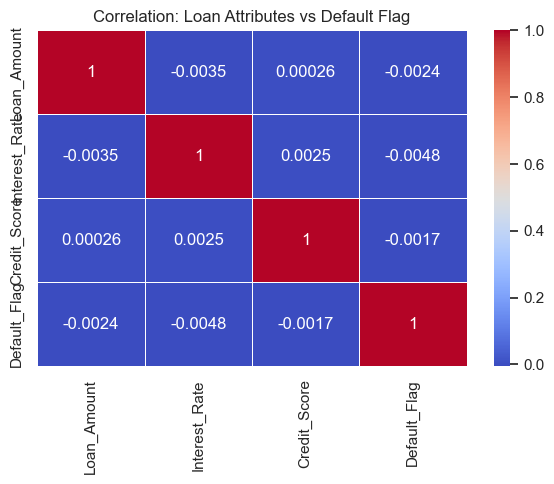


Correlation with Default_Flag:
Interest_Rate   -0.004763
Loan_Amount     -0.002401
Credit_Score    -0.001724
Name: Default_Flag, dtype: float64


In [16]:
#Check the Correlation between loan attributes and Default_Flag
corr_cols = ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
corr = loan_customer[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True,  cmap='coolwarm', linewidths=0.5)
plt.title('Correlation: Loan Attributes vs Default Flag')
plt.tight_layout()
plt.show()

print("\nCorrelation with Default_Flag:")
print(corr['Default_Flag'].drop('Default_Flag').sort_values())


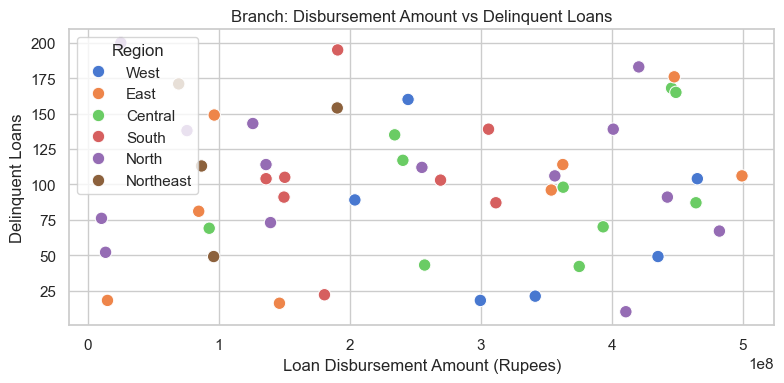

In [17]:
#Chek the branch performance vs defaults by scatter plots
plt.figure(figsize=(8, 4))
sns.scatterplot(data=branches, x='Loan_Disbursement_Amount', y='Delinquent_Loans',
                hue='Region', s=80)
plt.title('Branch: Disbursement Amount vs Delinquent Loans')
plt.xlabel('Loan Disbursement Amount (Rupees)')
plt.ylabel('Delinquent Loans')
plt.tight_layout()
plt.show()


---
## Task 4 – Branch & Regional Performance

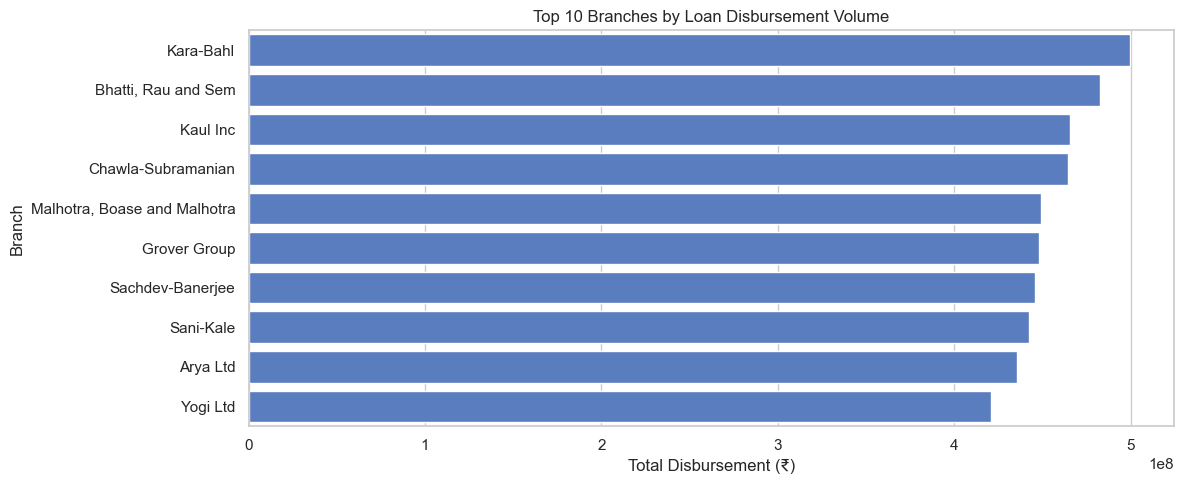

In [18]:
#I ranked the branches by disbursement volume of the loans
top_disbursement = branches.sort_values('Loan_Disbursement_Amount', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_disbursement, y='Branch_Name', x='Loan_Disbursement_Amount')
plt.title('Top 10 Branches by Loan Disbursement Volume')
plt.xlabel('Total Disbursement (₹)')
plt.ylabel('Branch')
plt.tight_layout()
plt.show()


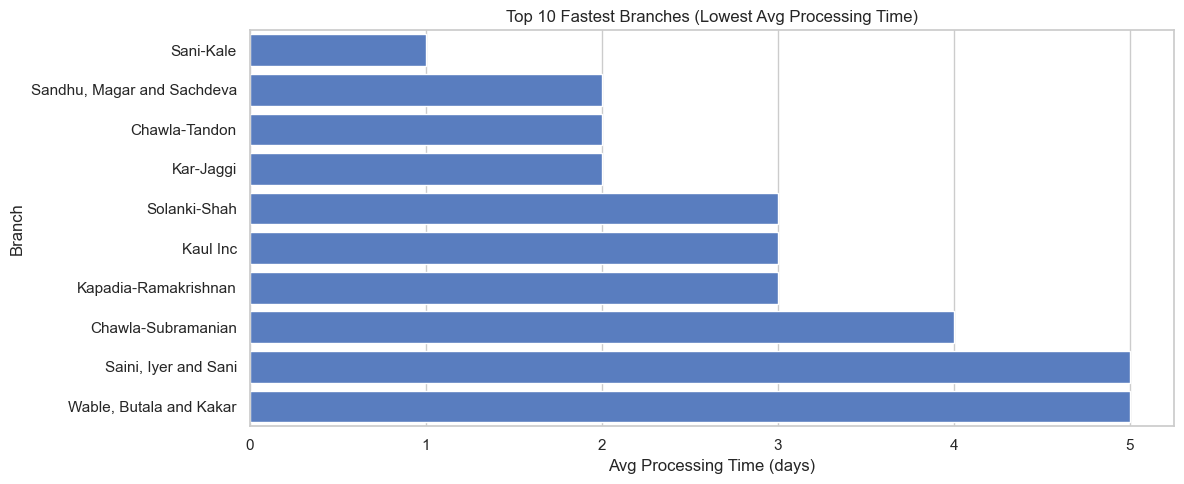

In [19]:
# 
# Using Avg_Processing_Time to chekc the efficiency
fastest_branches = branches.sort_values('Avg_Processing_Time').head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=fastest_branches, y='Branch_Name', x='Avg_Processing_Time'
            )
plt.title('Top 10 Fastest Branches (Lowest Avg Processing Time)')
plt.xlabel('Avg Processing Time (days)')
plt.ylabel('Branch')
plt.tight_layout()
plt.show()


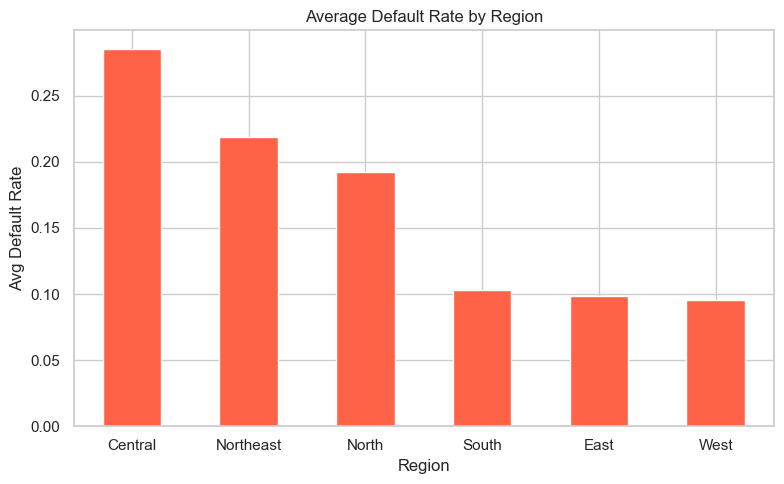

In [20]:
#Ploting default rates & their comparison across regions
branches['Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']
region_avg = branches.groupby('Region')['Default_Rate'].mean().sort_values(ascending=False)


plt.figure(figsize=(8, 5))
region_avg.plot(kind='bar', color='tomato', edgecolor='white')

plt.title('Average Default Rate by Region')
plt.ylabel('Avg Default Rate')
plt.xlabel('Region')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [21]:
#Table to summarise it
print(branches.groupby('Region')['Default_Rate'].describe())

           count      mean       std       min       25%       50%       75%  \
Region                                                                         
Central     10.0  0.285097  0.411850  0.026092  0.061130  0.106093  0.268896   
East         8.0  0.098763  0.065093  0.009735  0.054227  0.116102  0.128143   
North       14.0  0.192330  0.143865  0.005173  0.086861  0.134200  0.316831   
Northeast    4.0  0.218954  0.309283  0.028571  0.067983  0.082984  0.233955   
South        8.0  0.103170  0.062191  0.028351  0.062346  0.094203  0.120726   
West         6.0  0.095160  0.119427  0.021687  0.033011  0.055752  0.071621   

                max  
Region               
Central    1.377049  
East       0.201835  
North      0.449153  
Northeast  0.681275  
South      0.221053  
West       0.335430  


---
## Task 5 – Customer Segmentation

In [22]:
#Segment customers by income, credit score, and loan status
def categorize_income(salary):
    if salary < 40000:
        return 'Low Income'
    elif salary < 80000:
        return 'Medium Income'
    else:
        return 'High Income'


def categorize_credit(score):
    if score < 600:
        return 'Low Credit'
    elif score < 750:
        return 'Medium Credit'
    else:
        return 'High Credit'


customers['Income_Group'] = customers['Annual_Income'].apply(categorize_income)
customers['Credit_Group'] = customers['Credit_Score'].apply(categorize_credit)


print("Income Group distribution:")
print(customers['Income_Group'].value_counts())

print("Credit Group distribution:")
print(customers['Credit_Group'].value_counts())


Income Group distribution:
Income_Group
High Income    70000
Name: count, dtype: int64
Credit Group distribution:
Credit_Group
Low Credit       38335
Medium Credit    18852
High Credit      12813
Name: count, dtype: int64


In [23]:
print("Income Group distribution:")
print(customers['Income_Group'].value_counts())
print("\nCredit Group distribution:")
print(customers['Credit_Group'].value_counts())

Income Group distribution:
Income_Group
High Income    70000
Name: count, dtype: int64

Credit Group distribution:
Credit_Group
Low Credit       38335
Medium Credit    18852
High Credit      12813
Name: count, dtype: int64


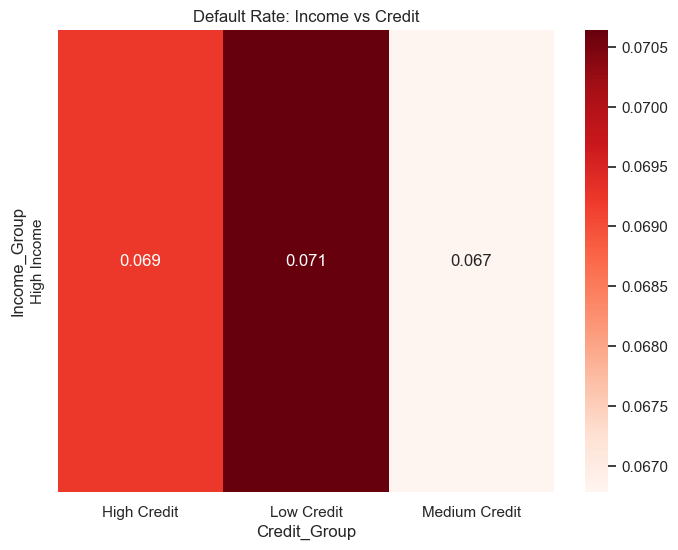

Top 3 High-Risk Groups:
Income_Group  Credit_Group 
High Income   Low Credit       0.070640
              High Credit      0.069227
              Medium Credit    0.066783
Name: Default_Flag, dtype: float64


In [24]:
#Again creat subset for using the required columns
#there should be a better way to do this
cust_default_flag = loan_customer[['Customer_ID', 'Default_Flag']].drop_duplicates('Customer_ID')

# Merge into our main customer table
customers = pd.merge(customers, cust_default_flag, on='Customer_ID', how='left')
customers['Default_Flag'] = customers['Default_Flag'].fillna(0)

#Risk heatmap and a table
risk_table = customers.groupby(['Income_Group', 'Credit_Group'])['Default_Flag'].mean()
heatmap_data = risk_table.unstack().fillna(0) 

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Reds')

plt.title('Default Rate: Income vs Credit')
plt.show()

print("Top 3 High-Risk Groups:")
print(risk_table.sort_values(ascending=False).head(3))


In [25]:
# Employment status to find the reembursment behaviour
emp_counts = customers.groupby(['Employment_Status', 'Default_Flag']).size().unstack(fill_value=0)
emp_counts.columns = ['No Default', 'Defaulted']
emp_counts['Total'] = emp_counts.sum(axis=1)
emp_counts['Default_Rate'] = emp_counts['Defaulted'] / emp_counts['Total']


print(emp_counts.sort_values('Default_Rate', ascending=False))


                   No Default  Defaulted  Total  Default_Rate
Employment_Status                                            
Self-Employed           21701       1645  23346      0.070462
Salaried                21836       1616  23452      0.068907
Unemployed              21609       1593  23202      0.068658


---
## Task 6 – Advanced Statistical Analysis

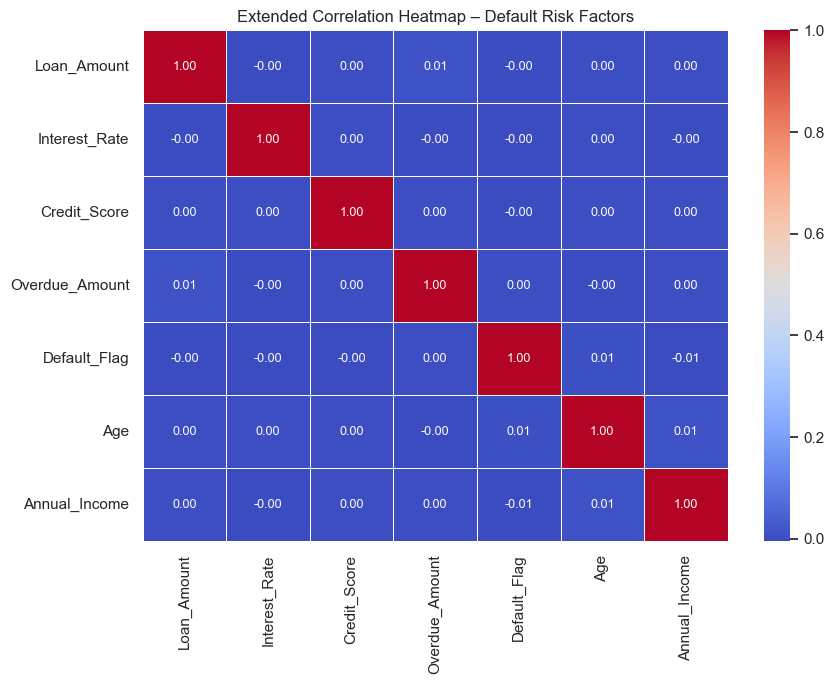

In [26]:
#correlation analysis for default risk

corr_cols_extended = ['Loan_Amount', 'Interest_Rate', 'Credit_Score',
                      'Overdue_Amount', 'Default_Flag', 'Age', 'Annual_Income']
corr_extended = loan_customer[corr_cols_extended].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_extended, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Extended Correlation Heatmap – Default Risk Factors')
plt.tight_layout()
plt.show()


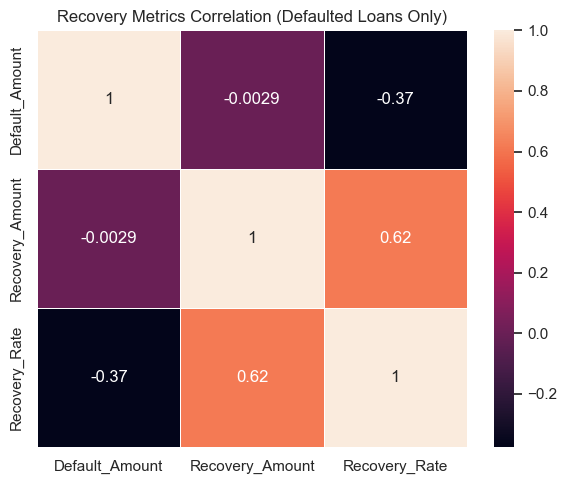

In [27]:
# Pairwise Correlation Heatmap
defaulted_loans = loan_default[loan_default['Default_Flag'] == 1].copy()
defaulted_loans['Recovery_Rate'] = (
    defaulted_loans['Recovery_Amount'] / defaulted_loans['Default_Amount']
)
defaulted_loans['Recovery_Rate'].replace([np.inf, -np.inf], 0, inplace=True)
defaulted_loans['Recovery_Rate'].fillna(0, inplace=True)

corr2 = defaulted_loans[['Default_Amount', 'Recovery_Amount', 'Recovery_Rate']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr2, annot=True, linewidths=0.5)
plt.title('Recovery Metrics Correlation (Defaulted Loans Only)')
plt.tight_layout()
plt.show()


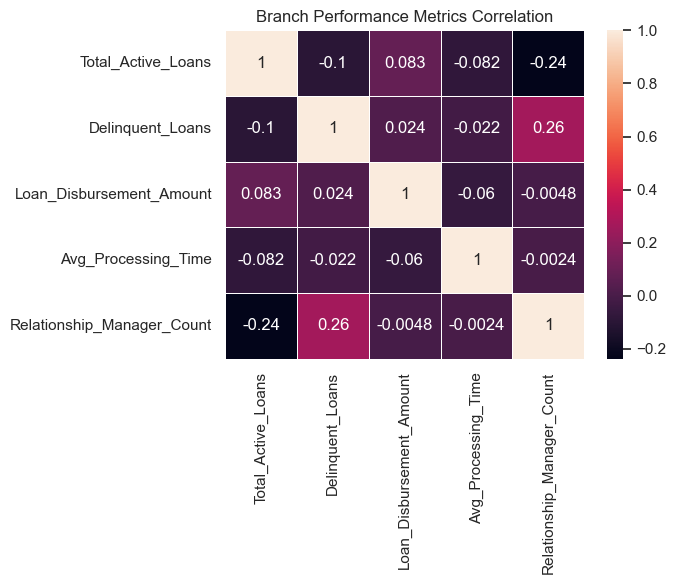

In [28]:
#Branch-level correlation
branch_corr = branches[['Total_Active_Loans', 'Delinquent_Loans',
                         'Loan_Disbursement_Amount', 'Avg_Processing_Time',
                         'Relationship_Manager_Count']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(branch_corr, annot=True, linewidths=0.5)
plt.title('Branch Performance Metrics Correlation')
plt.tight_layout()
plt.show()


---
## Task 7 – Transaction & Recovery Analysis

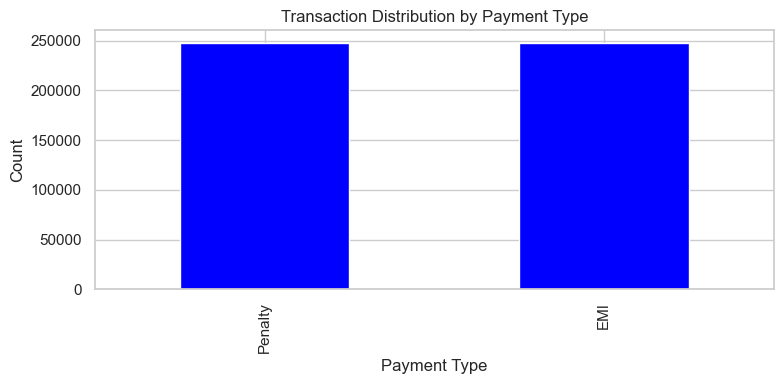

Payment Type Counts:
Payment_Type
Penalty    247844
EMI        247156
Name: count, dtype: int64


In [29]:
# Payment type distribution
plt.figure(figsize=(8, 4))
transactions['Payment_Type'].value_counts().plot(kind='bar', color='blue')
plt.title('Transaction Distribution by Payment Type')
plt.ylabel('Count')
plt.xlabel('Payment Type')
plt.xticks()
plt.tight_layout()
plt.show()

print("Payment Type Counts:")
print(transactions['Payment_Type'].value_counts())


In [30]:
# Analyze penalty payments and overdue trends. 
total_amount  = transactions['Amount'].sum()
total_overdue = transactions['Overdue_Fee'].sum()
overdue_ratio = total_overdue / total_amount

print(f"Total Transaction Amount : ₹{total_amount:,.0f}")
print(f"Total Overdue Fees       : ₹{total_overdue:,.0f}")
print(f"Overdue Fee Ratio        : {overdue_ratio:.2%}")


Total Transaction Amount : ₹12,620,730,053
Total Overdue Fees       : ₹630,299,779
Overdue Fee Ratio        : 4.99%


In [31]:
#Checking recovery from defaults dataset
print("Recovery Status Breakdown:")
print(defaults['Recovery_Status'].value_counts())

recovery_by_reason = defaults.groupby('Default_Reason').agg(
    Avg_Default_Amount  = ('Default_Amount',  'mean'),
    Avg_Recovery_Amount = ('Recovery_Amount', 'mean'),
    Count               = ('Default_ID',      'count')
).round(0)
recovery_by_reason['Recovery_Rate_%'] = (
    recovery_by_reason['Avg_Recovery_Amount'] /
    recovery_by_reason['Avg_Default_Amount'] * 100
).round(1)

print(recovery_by_reason.sort_values('Recovery_Rate_%', ascending=False))


Recovery Status Breakdown:
Recovery_Status
Partial    3010
Full       3005
0          2985
Name: count, dtype: int64
                   Avg_Default_Amount  Avg_Recovery_Amount  Count  \
Default_Reason                                                      
Medical Emergency             52645.0              13379.0   2262   
Business Failure              53359.0              13050.0   2285   
Other                         53345.0              12648.0   2293   
Job Loss                      52536.0              12424.0   2160   

                   Recovery_Rate_%  
Default_Reason                      
Medical Emergency             25.4  
Business Failure              24.5  
Other                         23.7  
Job Loss                      23.6  


---
## Task 8: EMI Analysis

In [32]:
# Analyze the relationship between EMI amounts and default probabilities. 

def calculate_emi(principal, annual_rate, months):
    """Standard EMI formula: P * r * (1+r)^n / ((1+r)^n - 1)"""
    r = annual_rate / (12 * 100)           # monthly interest rate
    return (principal * r * (1 + r)**months) / ((1 + r)**months - 1)

# Calculate EMI on loan_default (has all loan columns)
#loan_default['Calc_EMI'] = calculate_emi(
   ## loan_default['Interest_Rate'],
   # loan_default['Loan_Term']
#)

#print("Calculated EMI vs stored EMI_Amount (first 5 rows):")
#print(loan_default[['Loan_ID','EMI_Amount','Calc_EMI']].head())


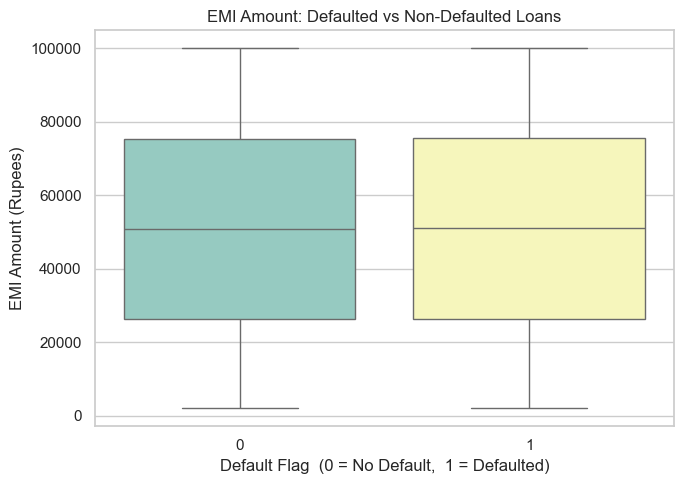


Avg EMI for non-defaulted: 50849.61360651109
Avg EMI for defaulted:     51056.049222222224


In [33]:
# Identify thresholds for EMI amounts where defaults are most likely. 
plt.figure(figsize=(7, 5))
sns.boxplot(data=loan_default, x='Default_Flag', y='EMI_Amount', palette='Set3')
plt.title('EMI Amount: Defaulted vs Non-Defaulted Loans')
plt.xlabel('Default Flag  (0 = No Default,  1 = Defaulted)')
plt.ylabel('EMI Amount (Rupees)')
plt.tight_layout()
plt.show()

print("\nAvg EMI for non-defaulted:", loan_default[loan_default['Default_Flag']==0]['EMI_Amount'].mean())
print("Avg EMI for defaulted:    ", loan_default[loan_default['Default_Flag']==1]['EMI_Amount'].mean())


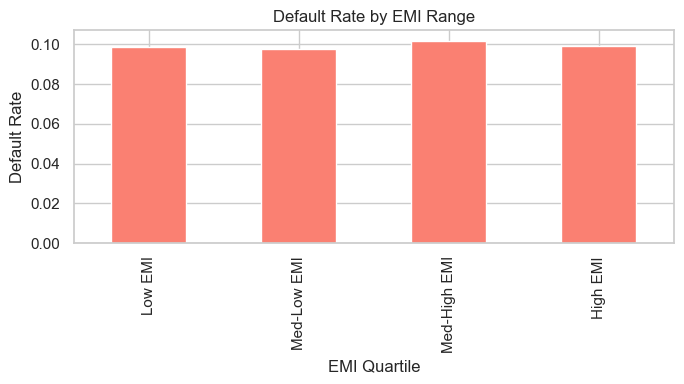

EMI_Bin
Low EMI         0.098793
Med-Low EMI     0.097854
Med-High EMI    0.101992
High EMI        0.099274
Name: Default_Flag, dtype: float64


In [34]:
# Compare EMI trends across loan types. 

max_emi = loan_default['EMI_Amount'].max()
step = max_emi / 4
emi_bins = [0, step, step*2, step*3, max_emi]
emi_labels = ['Low EMI', 'Med-Low EMI', 'Med-High EMI', 'High EMI']


loan_default['EMI_Bin'] = pd.cut(loan_default['EMI_Amount'], bins=emi_bins, labels=emi_labels)

emi_default_rate = loan_default.groupby('EMI_Bin')['Default_Flag'].mean()

# Chart
plt.figure(figsize=(7, 4))
emi_default_rate.plot(kind='bar', color='salmon', edgecolor='white')

plt.title('Default Rate by EMI Range')
plt.ylabel('Default Rate')
plt.xlabel('EMI Quartile')
plt.tight_layout()
plt.show()

print(emi_default_rate)


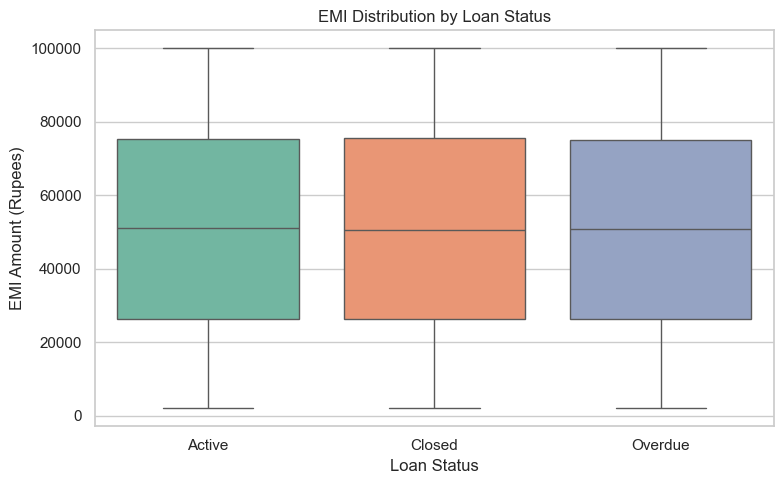

In [35]:
#ploting the EMI vs status of the loan
plt.figure(figsize=(8, 5))
sns.boxplot(data=loan_default, x='Loan_Status', y='EMI_Amount', palette='Set2')
plt.title('EMI Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('EMI Amount (Rupees)')
plt.xticks()
plt.tight_layout()
plt.show()


---
## Task 9: Loan Application Insights

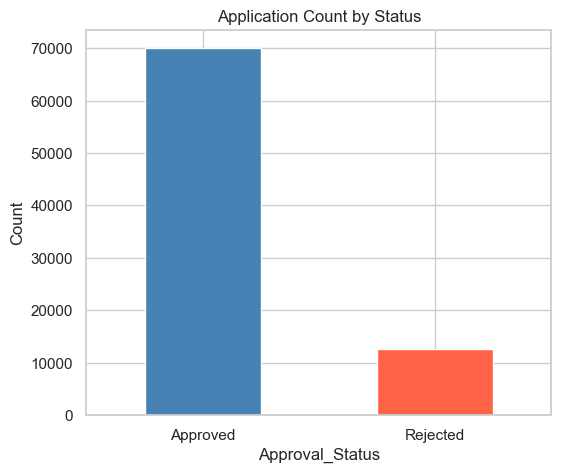

In [36]:
## Calculate approval and rejection rates for loan applications

approval_counts = applications['Approval_Status'].value_counts()
plt.figure(figsize=(6, 5))
approval_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Application Count by Status')
plt.ylabel('Count')
plt.xticks(rotation=0) 

plt.show()


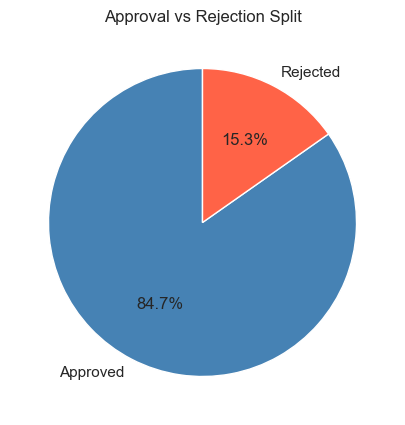

In [37]:
# Pie Chart for the same
approval_counts = applications['Approval_Status'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(approval_counts, labels=approval_counts.index, autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)

plt.title('Approval vs Rejection Split')
plt.show()

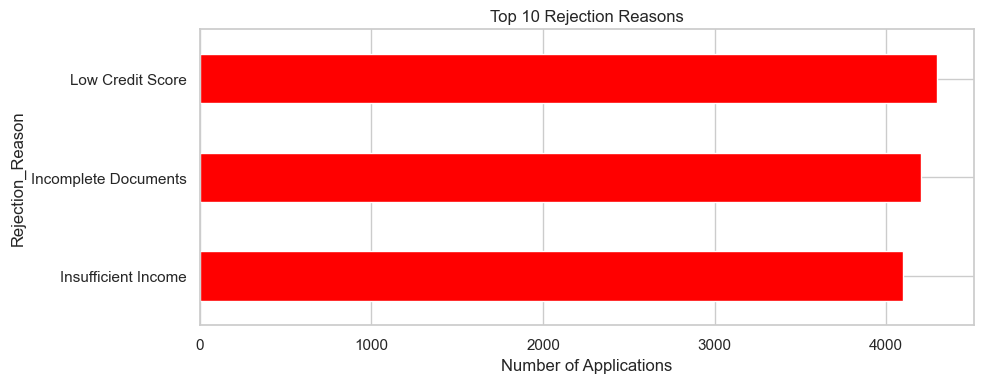

Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64


In [38]:
#Identify the most common reasons for loan rejection. 
rejected = applications[applications['Approval_Status'] == 'Rejected']
reason_counts = rejected['Rejection_Reason'].value_counts().head(10)

plt.figure(figsize=(10, 4))
reason_counts.plot(kind='barh', color='red')

plt.title('Top 10 Rejection Reasons')
plt.xlabel('Number of Applications')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


print(reason_counts)


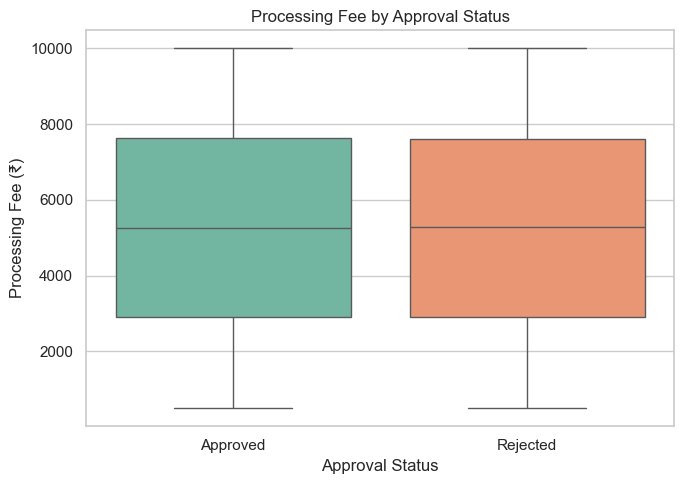

Approval_Status
Approved    5252.40
Rejected    5255.14
Name: Processing_Fee, dtype: float64


In [39]:
# Compare application processing fees between approved and rejected applications. 
plt.figure(figsize=(7, 5))
sns.boxplot(data=applications, x='Approval_Status', y='Processing_Fee', palette='Set2')
plt.title('Processing Fee by Approval Status')
plt.xlabel('Approval Status')
plt.ylabel('Processing Fee (₹)')
plt.tight_layout()
plt.show()


print(applications.groupby('Approval_Status')['Processing_Fee'].mean().round(2))


---
## Task 10: Recovery Effectiveness

In [40]:
#Determine the effectiveness of recovery efforts by calculating the ratio of Recovery_Amount to Default_Amount.

defaulted_loans['Recovery_Ratio'] = (
    defaulted_loans['Recovery_Amount'] / defaulted_loans['Default_Amount']
)
defaulted_loans['Recovery_Ratio'].replace([np.inf, -np.inf], 0, inplace=True)
defaulted_loans['Recovery_Ratio'].fillna(0, inplace=True)

print("Recovery Ratio Summary:")
print(defaulted_loans['Recovery_Ratio'].describe().round(3))


Recovery Ratio Summary:
count    9000.000
mean        0.405
std         0.831
min         0.000
25%         0.000
50%         0.023
75%         0.483
max         9.547
Name: Recovery_Ratio, dtype: float64


In [41]:
print(f"\nOverall Avg Recovery Rate: {defaulted_loans['Recovery_Ratio'].mean():.1%}")



Overall Avg Recovery Rate: 40.5%


In [42]:
#Adding columns that were missed during merge
default_cols = ['Loan_ID', 'Default_Amount','Default_Reason', 'Recovery_Amount', 'Legal_Action']
defaulted_loans = pd.merge(loans, defaults[default_cols], on='Loan_ID', how='inner')
defaulted_loans['Recovery_Ratio'] = defaulted_loans['Recovery_Amount'] / defaulted_loans['Default_Amount']

legal_recovery = defaulted_loans.groupby('Legal_Action')['Recovery_Ratio'].mean()


In [43]:
print(defaulted_loans.columns)


Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Default_Amount', 'Default_Reason', 'Recovery_Amount', 'Legal_Action',
       'Recovery_Ratio'],
      dtype='object')


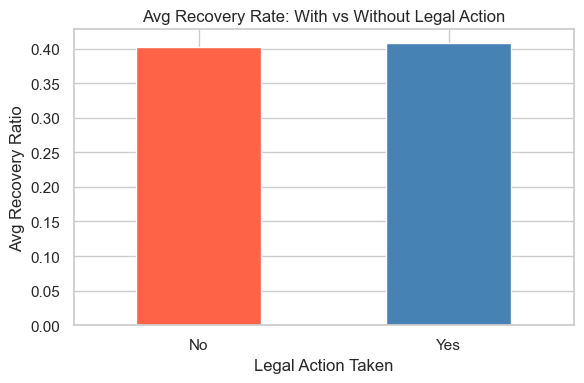


Recovery Rate – Legal Action vs None:
Legal_Action
No     0.402
Yes    0.407
Name: Recovery_Ratio, dtype: float64


In [44]:
# Compare recovery rates for defaults with and without legal actions by using a grpgh
legal_recovery = defaulted_loans.groupby('Legal_Action')['Recovery_Ratio'].mean()

plt.figure(figsize=(6, 4))
legal_recovery.plot(kind='bar', color=['tomato','steelblue'], edgecolor='white')
plt.title('Avg Recovery Rate: With vs Without Legal Action')
plt.ylabel('Avg Recovery Ratio')
plt.xlabel('Legal Action Taken')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nRecovery Rate – Legal Action vs None:")
print(legal_recovery.round(3))


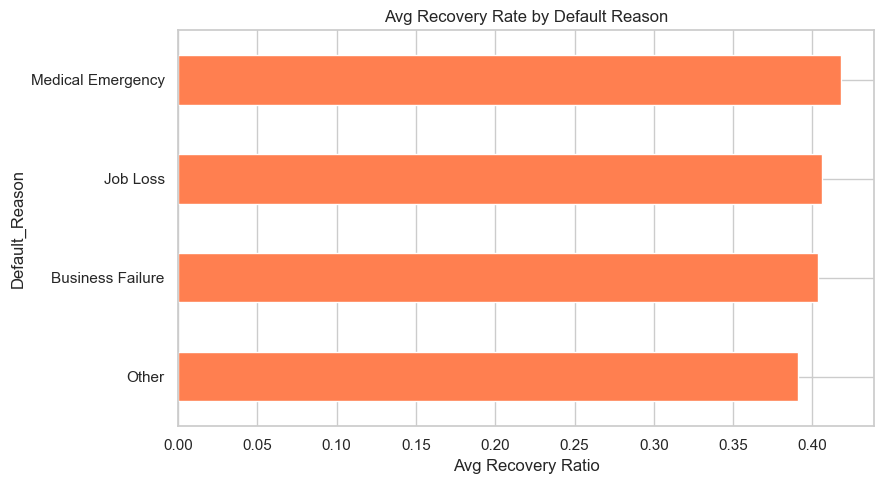

In [45]:
#Analyze branch-wise recovery performance.
reason_recovery = defaulted_loans.groupby('Default_Reason')['Recovery_Ratio'].mean().sort_values()

plt.figure(figsize=(9, 5))
reason_recovery.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Avg Recovery Rate by Default Reason')
plt.xlabel('Avg Recovery Ratio')
plt.tight_layout()
plt.show()


---
## Task 11: Loan Disbursement Efficiency

In [46]:
# Analyze the time from application to loan disbursement and identify bottlenecks

applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'])
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'])

applications['Processing_Days'] = (
    applications['Approval_Date'] - applications['Application_Date']
).dt.days

# Some rows may be negative (data issue) or NaN – filter those out
valid_apps = applications[applications['Processing_Days'] >= 0].copy()




In [47]:
print(f"Valid applications with processing time: {len(valid_apps)}")
print("\nProcessing Days Summary:")
print(valid_apps['Processing_Days'].describe().round(1))

Valid applications with processing time: 40573

Processing Days Summary:
count    40573.0
mean       745.7
std        512.5
min          0.0
25%        320.0
50%        658.0
75%       1107.0
max       2181.0
Name: Processing_Days, dtype: float64


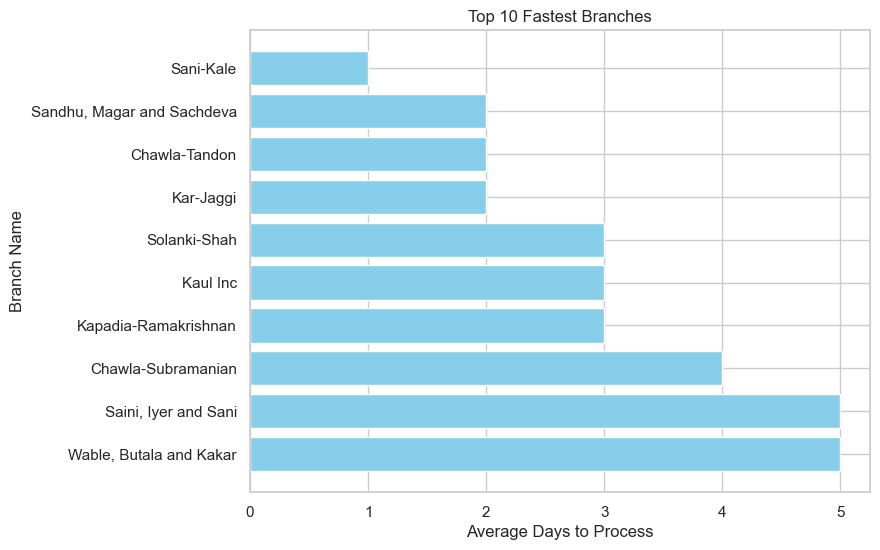

In [48]:
#Compare average processing times across branches.
top_branches = branches.sort_values('Avg_Processing_Time').head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_branches['Branch_Name'], top_branches['Avg_Processing_Time'], color='skyblue')

plt.title('Top 10 Fastest Branches')
plt.xlabel('Average Days to Process')
plt.ylabel('Branch Name')
plt.gca().invert_yaxis() 

plt.show()


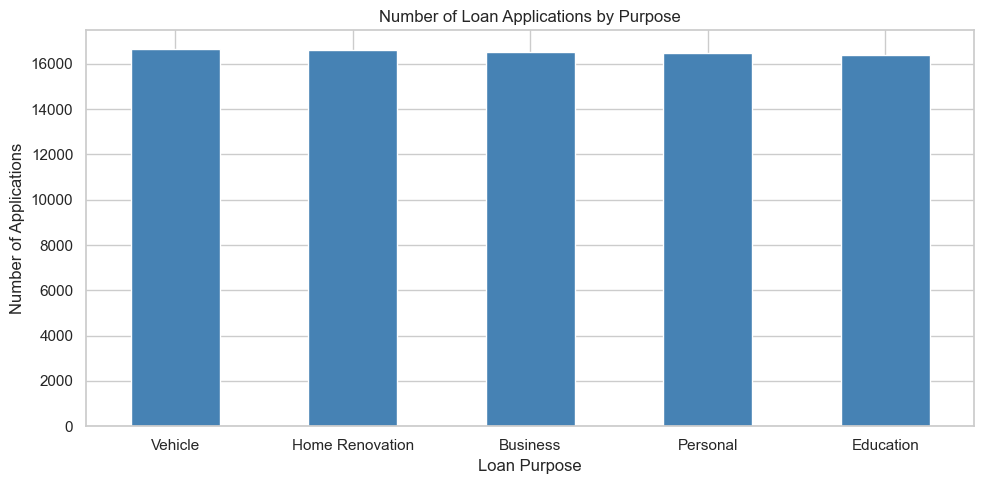

In [49]:
# Evaluate disbursement trends by loan purpose and region.
purpose_dist = applications.groupby('Loan_Purpose').size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
purpose_dist.plot(kind='bar', color='steelblue')
plt.title('Number of Loan Applications by Purpose')
plt.ylabel('Number of Applications')
plt.xlabel('Loan Purpose')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Task 12 – Profitability Analysis

In [50]:
# Calculate the total interest income generated across all loans.
annual_interest = loans['Loan_Amount'] * (loans['Interest_Rate'] / 100)
loans['Interest_Income'] = annual_interest * (loans['Loan_Term'] / 12)

total_income = loans['Interest_Income'].sum()
average_income = loans['Interest_Income'].mean()


print("Total Interest Income:")
print(round(total_income))
print("Average Interest Income per loan:")
print(round(average_income))


Total Interest Income:
75037526935
Average Interest Income per loan:
833750


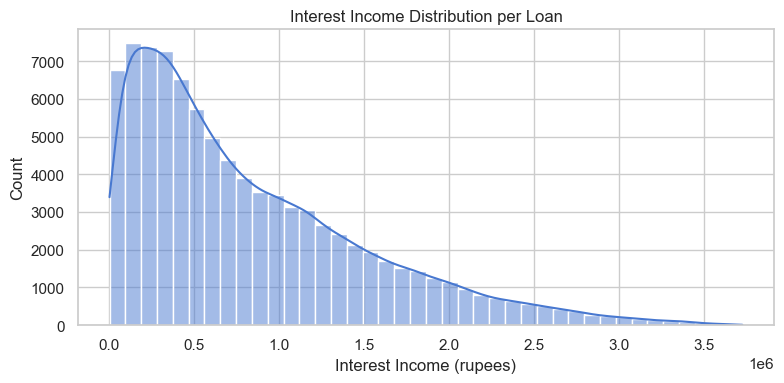

In [51]:
#plot the calculated interest
plt.figure(figsize=(8, 4))
sns.histplot(loans['Interest_Income'], bins=40, kde=True)
plt.title('Interest Income Distribution per Loan')
plt.xlabel('Interest Income (rupees)')
plt.tight_layout()
plt.show()


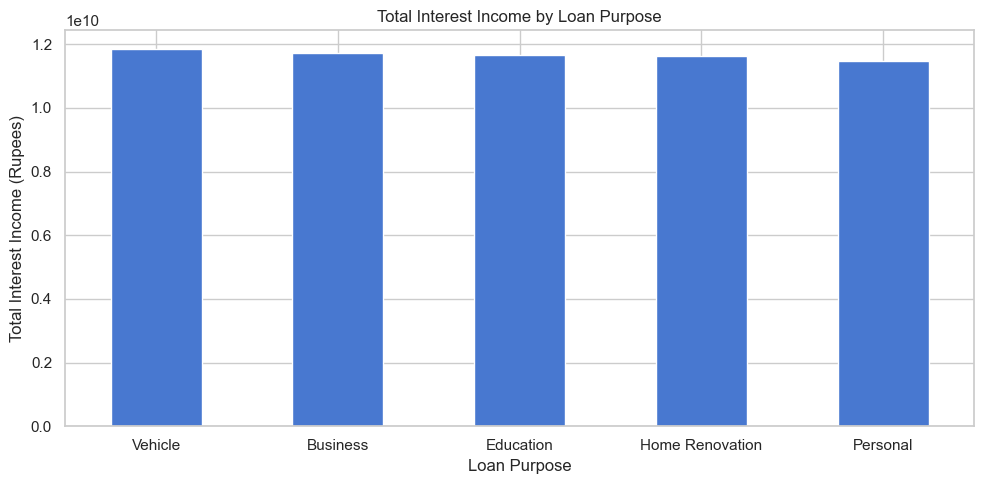


Top 5 Most Profitable Loan Purposes:
Loan_Purpose
Vehicle            1.184490e+10
Business           1.174041e+10
Education          1.166138e+10
Home Renovation    1.162827e+10
Personal           1.146694e+10
Name: Interest_Income, dtype: float64


In [52]:
# Identify the most profitable loan purposes based on interest earnings

loan_purpose = loans.merge(applications[['Loan_ID','Loan_Purpose']], on='Loan_ID', how='left')
purpose_profit = loan_purpose.groupby('Loan_Purpose')['Interest_Income'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
purpose_profit.plot(kind='bar', edgecolor='white')
plt.title('Total Interest Income by Loan Purpose')
plt.ylabel('Total Interest Income (Rupees)')
plt.xlabel('Loan Purpose')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Profitable Loan Purposes:")
print(purpose_profit.head())


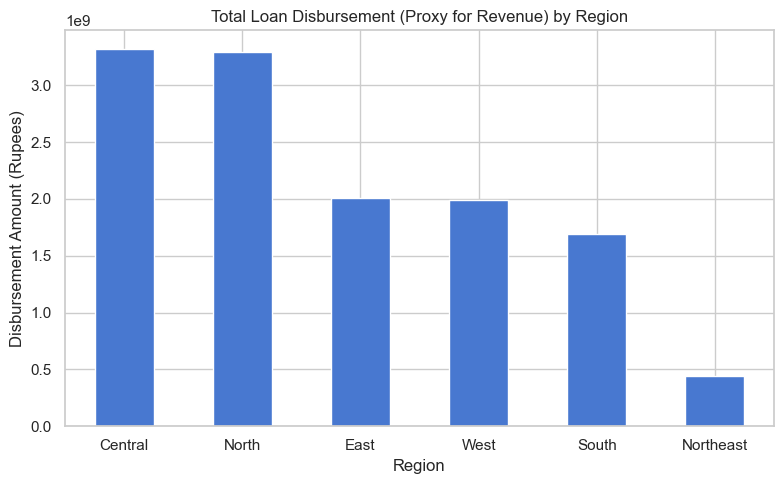

In [53]:
#Compare profitability metrics for branches across regions. 
region_profit = branches.groupby('Region')['Loan_Disbursement_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_profit.plot(kind='bar', edgecolor='white')
plt.title('Total Loan Disbursement (Proxy for Revenue) by Region')
plt.ylabel('Disbursement Amount (Rupees)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Task 13 – Geospatial / Regional Analysis

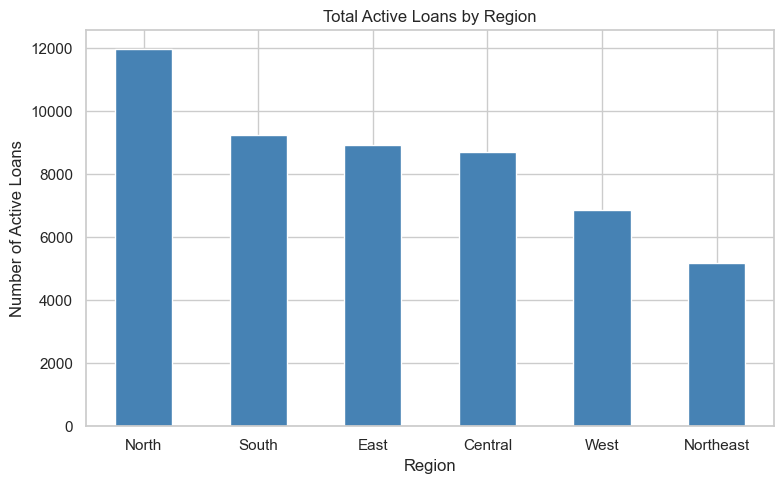

In [54]:
#Map the distribution of active loans across regions.
region_active = branches.groupby('Region')['Total_Active_Loans'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_active.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Active Loans by Region')
plt.ylabel('Number of Active Loans')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


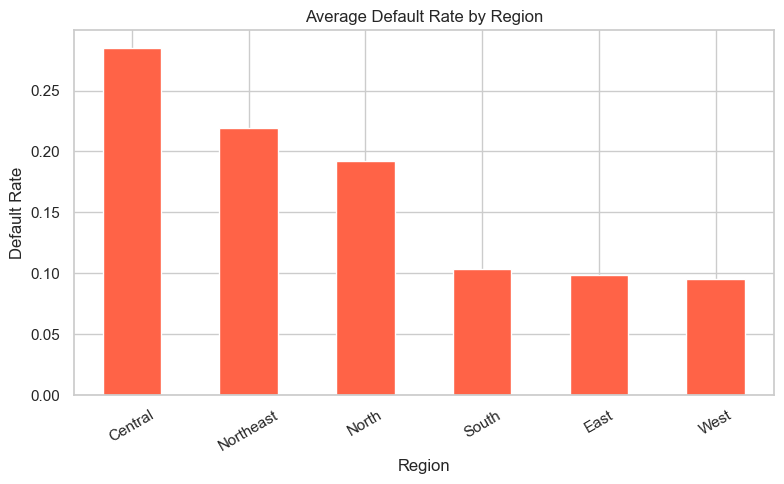

In [55]:
#Compare default rates across different geographic regions
branches['Default_Rate'] = branches['Delinquent_Loans'] / branches['Total_Active_Loans']
region_default_rate = branches.groupby('Region')['Default_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_default_rate.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Average Default Rate by Region')
plt.ylabel('Default Rate')
plt.xlabel('Region')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


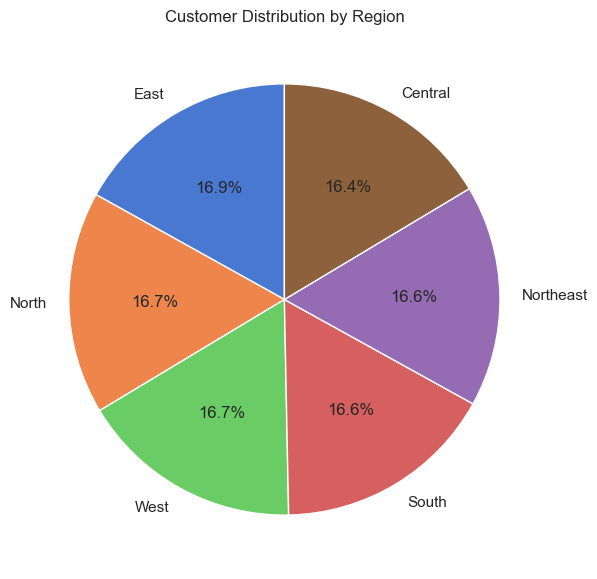

In [56]:
#Visualize the loan disbursement trends for rural vs. urban areas. 
cust_by_region = customers['Region'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(cust_by_region, 
        labels=cust_by_region.index, 
        autopct='%1.1f%%', 
        startangle=90)
plt.title('Customer Distribution by Region')


plt.show()


#Visualize the loan disbursement trends for rural vs. urban areas
cust_by_region = customers['Region'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cust_by_region.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Customer Count by Region')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(cust_by_region, labels=cust_by_region.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Customer Distribution by Region')

plt.tight_layout()
plt.show()


---
## Task 14 – Default Trends

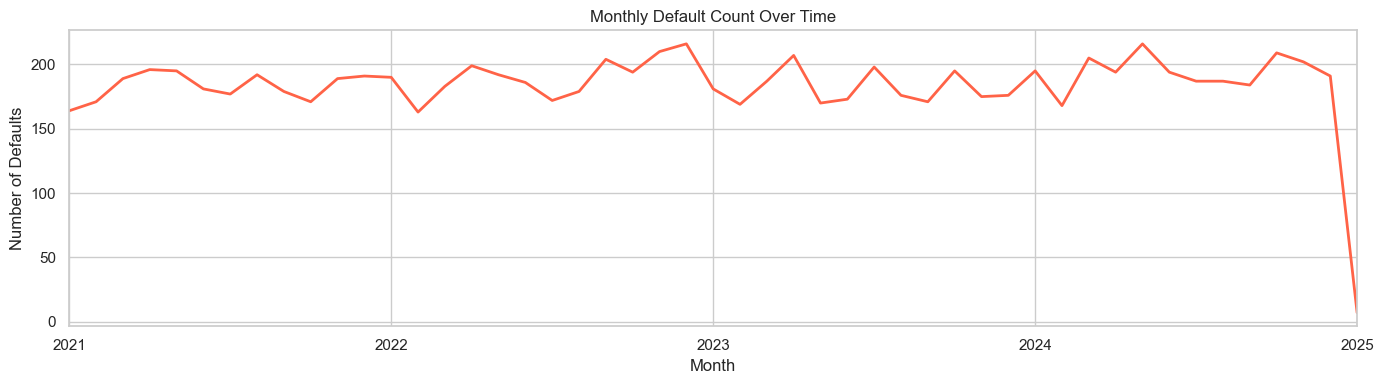

In [57]:
# Analyze the number of defaults over time to identify patterns.
defaults['Month'] = defaults['Default_Date'].dt.to_period('M')
monthly_defaults  = defaults.groupby('Month').size()

plt.figure(figsize=(14, 4))
monthly_defaults.plot(color='tomato', linewidth=2)
plt.title('Monthly Default Count Over Time')
plt.ylabel('Number of Defaults')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


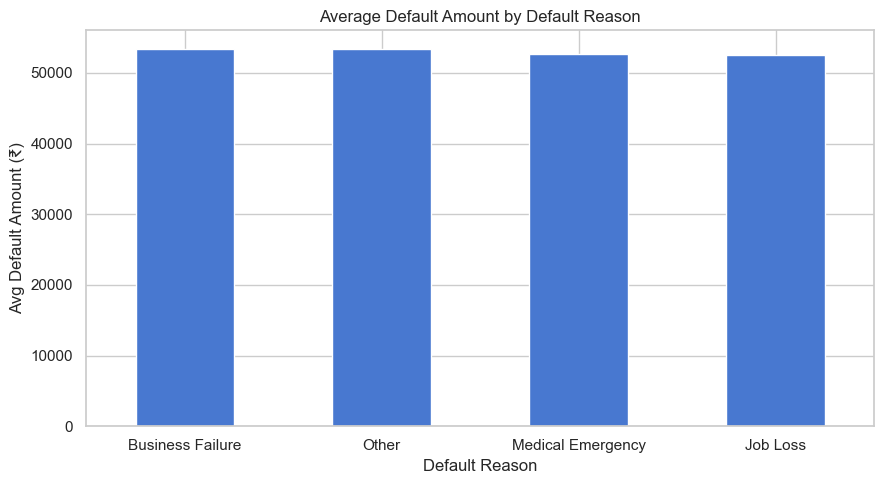

In [58]:
#Calculate the average default amount for different loan purposes
avg_default_reason = defaults.groupby('Default_Reason')['Default_Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_default_reason.plot(kind='bar', edgecolor='white')
plt.title('Average Default Amount by Default Reason')
plt.ylabel('Avg Default Amount (₹)')
plt.xlabel('Default Reason')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


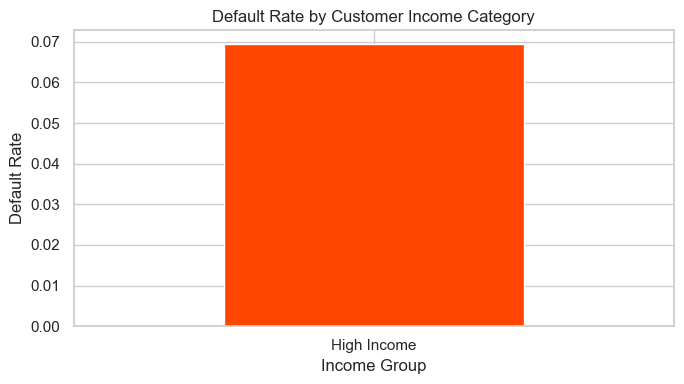

Income_Group
High Income    0.069
Name: Default_Flag, dtype: float64


In [59]:
# Compare default rates across customer income categories.
income_default = customers.groupby('Income_Group')['Default_Flag'].mean()

plt.figure(figsize=(7, 4))
income_default.plot(kind='bar', color='orangered', edgecolor='white')
plt.title('Default Rate by Customer Income Category')
plt.ylabel('Default Rate')
plt.xlabel('Income Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(income_default.round(3))


---
## Task 15: Branch Efficiency

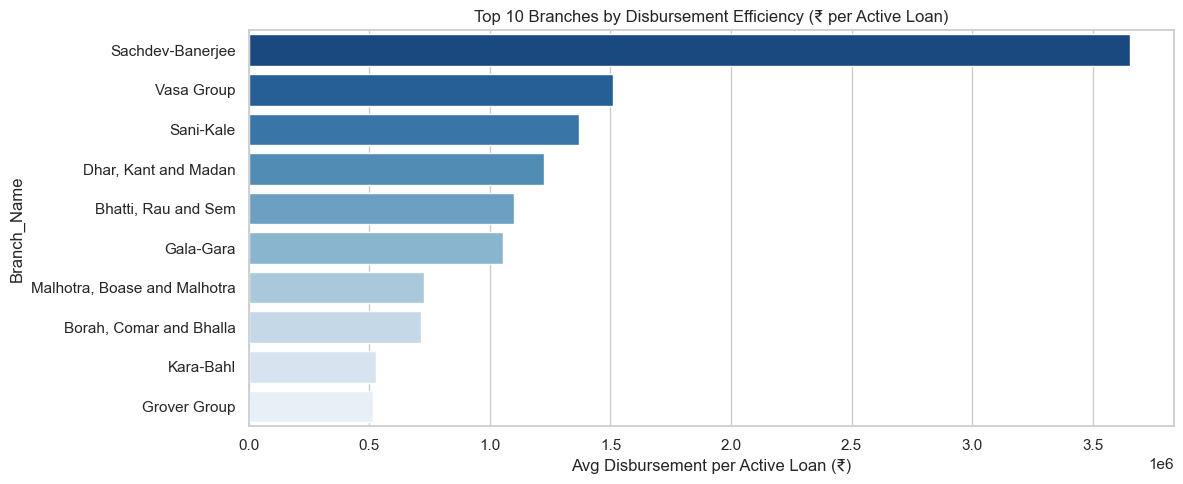

In [60]:
# Calculate the average loan disbursement time for each branch. 
branches['Disbursement_Efficiency'] = (
    branches['Loan_Disbursement_Amount'] / branches['Total_Active_Loans']
)

top_efficient = branches.nlargest(10, 'Disbursement_Efficiency')

plt.figure(figsize=(12, 5))
sns.barplot(data=top_efficient, y='Branch_Name', x='Disbursement_Efficiency', palette='Blues_r')
plt.title('Top 10 Branches by Disbursement Efficiency (₹ per Active Loan)')
plt.xlabel('Avg Disbursement per Active Loan (₹)')
plt.tight_layout()
plt.show()


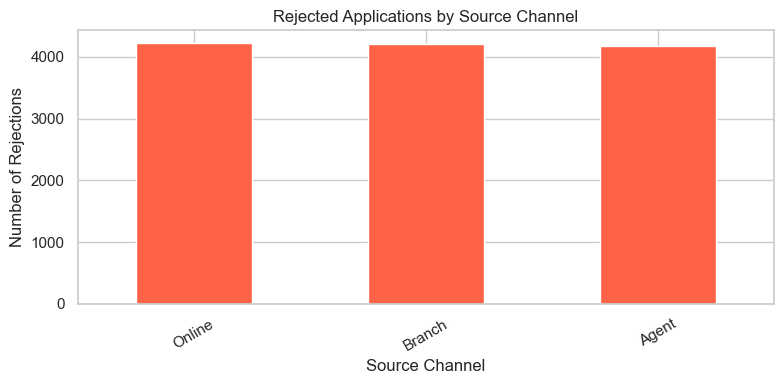

In [61]:
#  Identify branches with the highest number of rejected applications
rejected_by_channel = applications[applications['Approval_Status']=='Rejected'] \
                      .groupby('Source_Channel').size().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
rejected_by_channel.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Rejected Applications by Source Channel')
plt.ylabel('Number of Rejections')
plt.xlabel('Source Channel')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


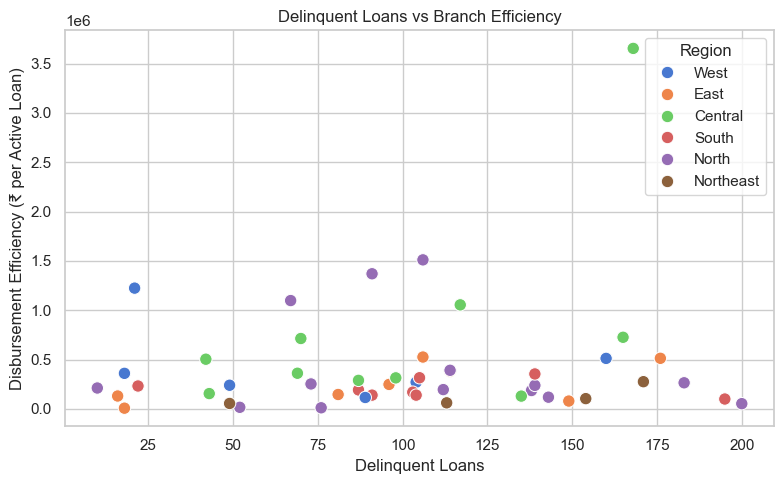

In [62]:
#Compare branch efficiency based on customer satisfaction metrics (if available). 
plt.figure(figsize=(8, 5))
sns.scatterplot(data=branches, x='Delinquent_Loans', y='Disbursement_Efficiency',
                hue='Region', s=80)
plt.title('Delinquent Loans vs Branch Efficiency')
plt.xlabel('Delinquent Loans')
plt.ylabel('Disbursement Efficiency (₹ per Active Loan)')
plt.tight_layout()
plt.show()


---
## Task 16 – Time-Series Analysis

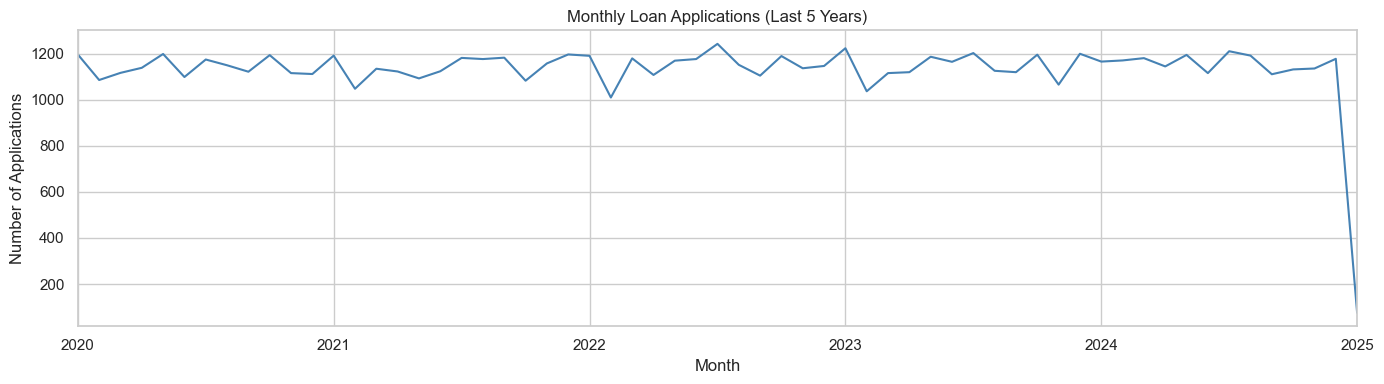

In [64]:
#Analyze monthly loan disbursement trends over the last 5 years.
applications['Month'] = applications['Application_Date'].dt.to_period('M')
monthly_apps = applications.groupby('Month').size()

# For 5 years
five_years_ago = pd.Period(applications['Application_Date'].max() - pd.DateOffset(years=5), 'M')
monthly_apps_5yr = monthly_apps[monthly_apps.index >= five_years_ago]

plt.figure(figsize=(14, 4))
monthly_apps_5yr.plot(color='steelblue')
plt.title('Monthly Loan Applications (Last 5 Years)')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()


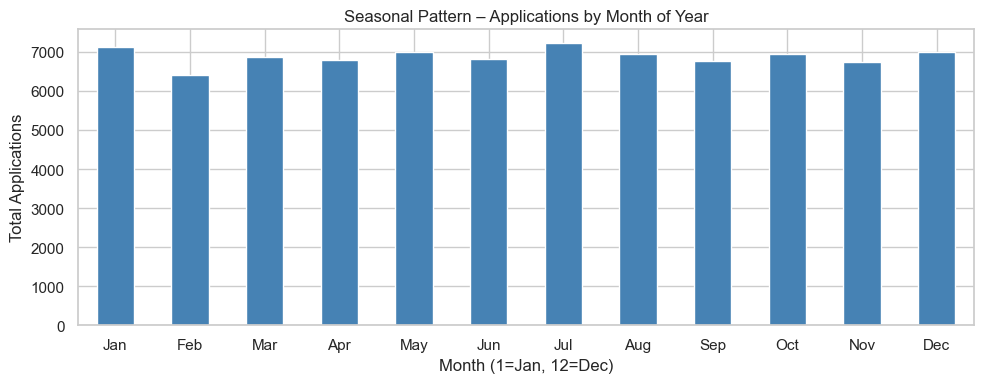

In [66]:
#Identify seasonal patterns in loan applications and disbursements. 
applications['Month_of_Year'] = applications['Application_Date'].dt.month
seasonal = applications.groupby('Month_of_Year').size()

plt.figure(figsize=(10, 4))
seasonal.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Seasonal Pattern – Applications by Month of Year')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Total Applications')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()


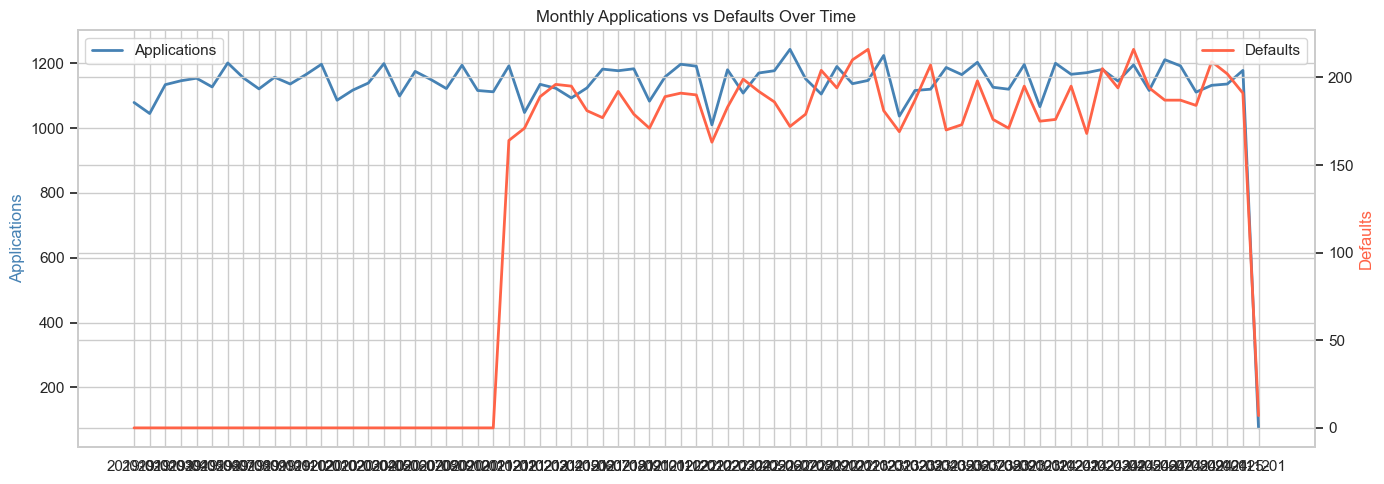

In [71]:
# Compare monthly default rates across regions. 

defaults['Month'] = defaults['Default_Date'].dt.to_period('M')
monthly_defaults  = defaults.groupby('Month').size()

combined = pd.DataFrame({
    'Applications': monthly_apps,
    'Defaults':     monthly_defaults
}).fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()   # second y-axis

ax1.plot(combined.index.astype(str), combined['Applications'],
         color='steelblue', linewidth=2, label='Applications')
ax2.plot(combined.index.astype(str), combined['Defaults'],
         color='tomato',    linewidth=2, label='Defaults')

ax1.set_ylabel('Applications', color='steelblue')
ax2.set_ylabel('Defaults',     color='tomato')
plt.title('Monthly Applications vs Defaults Over Time')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


---
## Task 17 – Customer Behavior Analysis

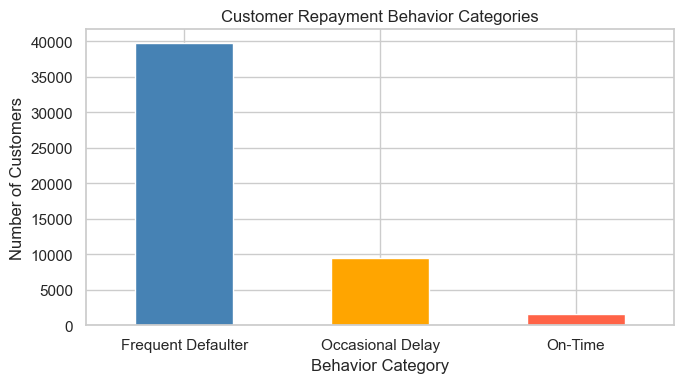

Customer Behavior Summary:
Behavior_Category
Frequent Defaulter    39656
Occasional Delay       9397
On-Time                1537
Name: count, dtype: int64


In [72]:
#Categorize customers based on their repayment behavior (e.g., always on time, occasional defaulters, frequent defaulters).

#Calculate penalty for each customer first
customer_behavior = transactions.groupby('Customer_ID').agg(
    Total_Amount  = ('Amount',      'sum'),
    Total_Overdue = ('Overdue_Fee', 'sum'),
    Num_Transactions = ('Transaction_ID', 'count')
).reset_index()

def categorize_behavior(overdue):
    if overdue == 0:
        return 'On-Time'
    elif overdue < 5000:
        return 'Occasional Delay'
    else:
        return 'Frequent Defaulter'

customer_behavior['Behavior_Category'] = customer_behavior['Total_Overdue'].apply(categorize_behavior)

plt.figure(figsize=(7, 4))
customer_behavior['Behavior_Category'].value_counts().plot(kind='bar',
    color=['steelblue','orange','tomato'], edgecolor='white')
plt.title('Customer Repayment Behavior Categories')
plt.ylabel('Number of Customers')
plt.xlabel('Behavior Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Customer Behavior Summary:")
print(customer_behavior['Behavior_Category'].value_counts())


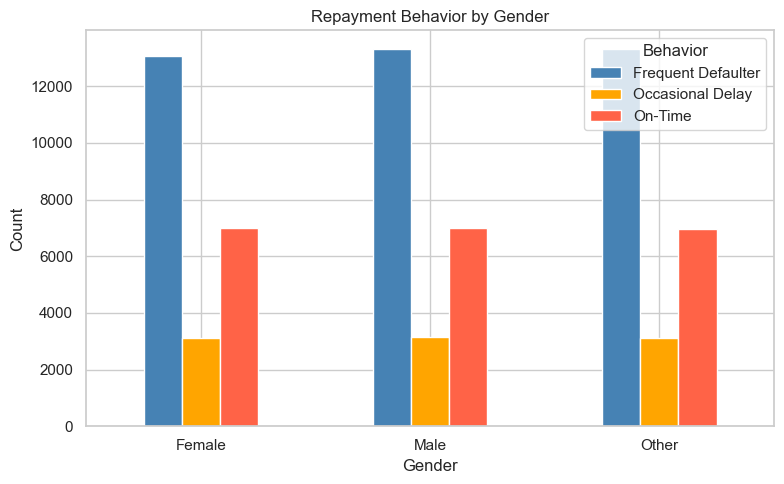

In [73]:
#Analyze patterns in loan approval and rejection reasons segmented by  customer demographics. 
customers_behavior = customers.merge(customer_behavior[['Customer_ID','Behavior_Category']],
                                     on='Customer_ID', how='left')
customers_behavior['Behavior_Category'].fillna('On-Time', inplace=True)

# Behavior by Gender
gender_behavior = customers_behavior.groupby(['Gender','Behavior_Category']).size().unstack(fill_value=0)
gender_behavior.plot(kind='bar', figsize=(8, 5), color=['steelblue','orange','tomato'],
                     edgecolor='white')
plt.title('Repayment Behavior by Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Behavior')
plt.tight_layout()
plt.show()


In [74]:
#Identify high-value customers with consistent repayment histories. 
high_value = customers_behavior[
    (customers_behavior['Behavior_Category'] == 'On-Time') &
    (customers_behavior['Income_Group'] == 'High Income')
]
print(f"High-value customers (On-Time + High Income): {len(high_value)}")
print(f"  Avg Credit Score : {high_value['Credit_Score'].mean():.0f}")
print(f"  Avg Annual Income: ₹{high_value['Annual_Income'].mean():,.0f}")


High-value customers (On-Time + High Income): 20947
  Avg Credit Score : 576
  Avg Annual Income: ₹1,098,669


---
## Task 18 – Risk Assessment

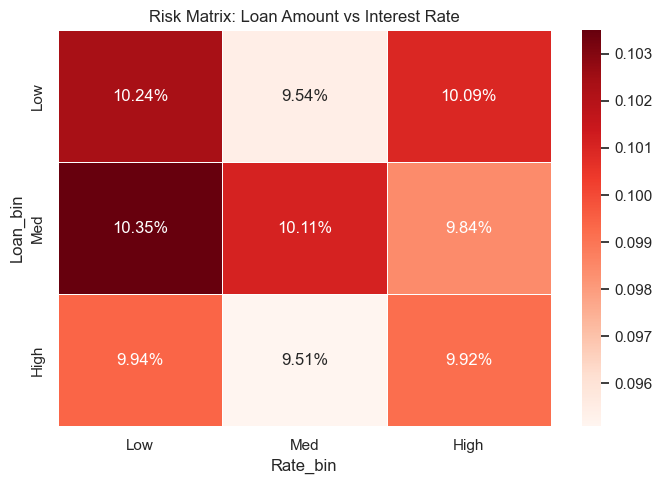

In [75]:
#Develop a risk matrix for loan products based on Default_Amount, Loan_Term, and Interest_Rate.
risk_data = loan_customer[['Loan_Amount','Interest_Rate','Loan_Term','Default_Flag']].copy()

risk_data['Loan_bin'] = pd.qcut(risk_data['Loan_Amount'],   3, labels=['Low','Med','High'])
risk_data['Rate_bin'] = pd.qcut(risk_data['Interest_Rate'], 3, labels=['Low','Med','High'])
risk_data['Term_bin'] = pd.qcut(risk_data['Loan_Term'],     3, labels=['Short','Med','Long'],
                                 duplicates='drop')

risk_matrix = risk_data.groupby(['Loan_bin','Rate_bin'])['Default_Flag'].mean()

plt.figure(figsize=(7, 5))
sns.heatmap(risk_matrix.unstack(), annot=True, fmt='.2%', cmap='Reds', linewidths=0.5)
plt.title('Risk Matrix: Loan Amount vs Interest Rate')
plt.tight_layout()
plt.show()


High-Risk Customers (Low Credit + Low Income): 0
  Avg Credit Score : nan
  Avg Annual Income: ₹nan
  Default Rate     : nan%


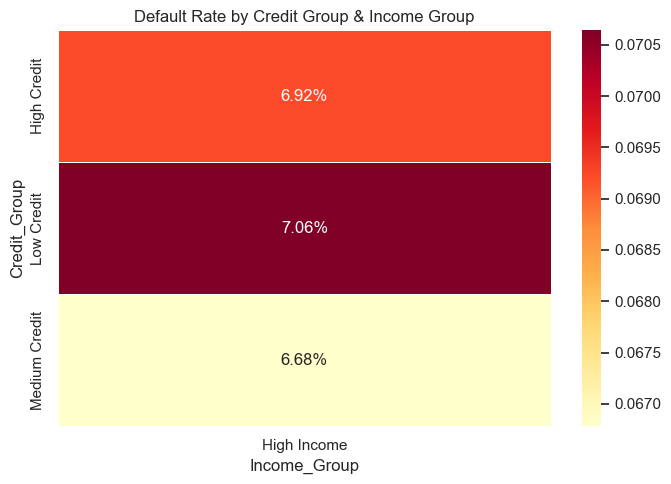

In [80]:
# Analyze high-risk customer segments by credit score and income
high_risk_customers = customers[
    (customers['Credit_Group'] == 'Low Credit') &
    (customers['Income_Group'] == 'Low Income')
]
print(f"High-Risk Customers (Low Credit + Low Income): {len(high_risk_customers)}")
print(f"  Avg Credit Score : {high_risk_customers['Credit_Score'].mean():.0f}")
print(f"  Avg Annual Income: ₹{high_risk_customers['Annual_Income'].mean():,.0f}")
print(f"  Default Rate     : {high_risk_customers['Default_Flag'].mean():.1%}")

# Overall risk by credit + income group
risk_by_segment = customers.groupby(['Credit_Group','Income_Group'])['Default_Flag'].mean()
plt.figure(figsize=(7, 5))
sns.heatmap(risk_by_segment.unstack(), annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5)
plt.title('Default Rate by Credit Group & Income Group')
plt.tight_layout()
plt.show()


---
## Task 19 – Time to Default Analysis

In [81]:
# Calculate the average time from loan disbursement to default for overdue loans.
loan_default_time = loans.merge(
    defaults[['Loan_ID','Default_Date','Default_Amount','Default_Reason']],
    on='Loan_ID', how='inner'   # inner = only loans that defaulted
)

# Calculate Time to Default = Default_Date - Disbursal_Date
loan_default_time['Days_to_Default'] = (
    loan_default_time['Default_Date'] - loan_default_time['Disbursal_Date']
).dt.days

# Remove negative or zero values (data errors)
loan_default_time = loan_default_time[loan_default_time['Days_to_Default'] > 0]

print(f"Defaulted loans with valid time data: {len(loan_default_time)}")
print("\nTime to Default (days) Summary:")
print(loan_default_time['Days_to_Default'].describe().round(1))


Defaulted loans with valid time data: 5575

Time to Default (days) Summary:
count    5575.0
mean      631.4
std       424.8
min         1.0
25%       277.5
50%       561.0
75%       931.5
max      1809.0
Name: Days_to_Default, dtype: float64


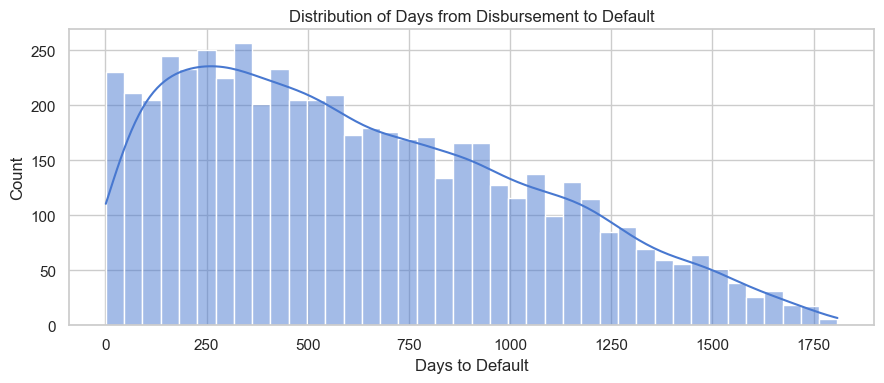

In [83]:
# Identify loan purposes with the shortest time to default.
plt.figure(figsize=(9, 4))
sns.histplot(loan_default_time['Days_to_Default'], bins=40, kde=True)
plt.title('Distribution of Days from Disbursement to Default')
plt.xlabel('Days to Default')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


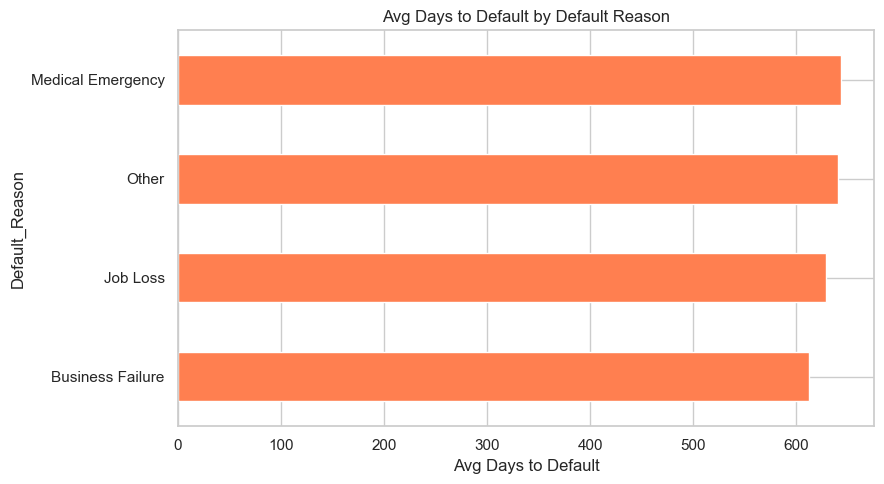


Quickest defaults by reason:
Default_Reason
Business Failure     612.3
Job Loss             628.7
Other                640.9
Medical Emergency    643.2
Name: Days_to_Default, dtype: float64


In [84]:
#Compare the time to default across customer demographics.
ttd_by_reason = loan_default_time.groupby('Default_Reason')['Days_to_Default'] \
                                  .mean().sort_values()

plt.figure(figsize=(9, 5))
ttd_by_reason.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Avg Days to Default by Default Reason')
plt.xlabel('Avg Days to Default')
plt.tight_layout()
plt.show()

print("\nQuickest defaults by reason:")
print(ttd_by_reason.round(1))


---
## Task 20 – Transaction Pattern Analysis

In [86]:
#Identify customers with irregular repayment patterns. 
txn_pattern = transactions.groupby('Customer_ID').agg(
    Total_Amount     = ('Amount',         'sum'),
    Total_Overdue    = ('Overdue_Fee',    'sum'),
    Num_Transactions = ('Transaction_ID', 'count')
).reset_index()

# Irregularity score = overdue fees / total amount paid
txn_pattern['Irregularity_Score'] = (
    txn_pattern['Total_Overdue'] / txn_pattern['Total_Amount']
)
txn_pattern['Irregularity_Score'].replace([np.inf, -np.inf], 0, inplace=True)
txn_pattern['Irregularity_Score'].fillna(0, inplace=True)

print("Top 10 Most Irregular Customers:")
print(txn_pattern.sort_values('Irregularity_Score', ascending=False).head(10))


Top 10 Most Irregular Customers:
      Customer_ID  Total_Amount  Total_Overdue  Num_Transactions  \
4685      C006469          1061           4324                 1   
6586      C009135          1276           3498                 1   
50017     C069206          1737           4275                 1   
2273      C003165          1605           3328                 1   
12135     C016929          1938           3561                 1   
40685     C056301          2371           4234                 1   
7265      C010092          3392           5394                 2   
24892     C034617          2882           3287                 1   
34568     C047870          4164           4495                 1   
24127     C033571          3333           3442                 1   

       Irregularity_Score  
4685             4.075401  
6586             2.741379  
50017            2.461140  
2273             2.073520  
12135            1.837461  
40685            1.785744  
7265             1.590

Total Transaction Amount : ₹12,620,730,053
Total Overdue Fees       : ₹630,299,779
Penalty as % of Total    : 4.99%


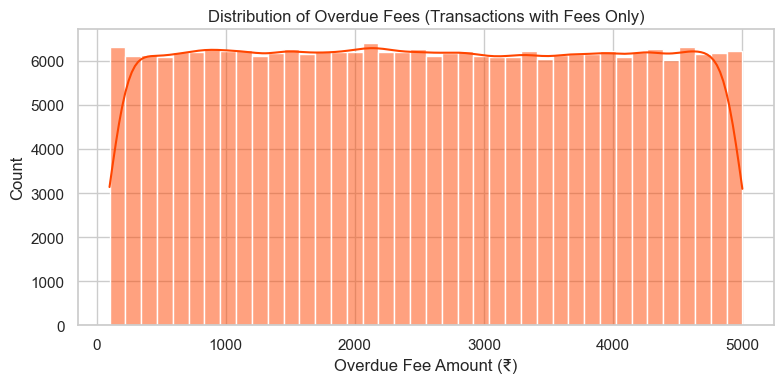

In [87]:
#Identify customers with irregular repayment patterns. 
total_txn_amount   = transactions['Amount'].sum()
total_overdue_fees = transactions['Overdue_Fee'].sum()
penalty_ratio      = total_overdue_fees / total_txn_amount

print(f"Total Transaction Amount : ₹{total_txn_amount:,.0f}")
print(f"Total Overdue Fees       : ₹{total_overdue_fees:,.0f}")
print(f"Penalty as % of Total    : {penalty_ratio:.2%}")

# Visualise overdue fee distribution
plt.figure(figsize=(8, 4))
sns.histplot(transactions[transactions['Overdue_Fee'] > 0]['Overdue_Fee'],
             bins=40, kde=True, color='orangered')
plt.title('Distribution of Overdue Fees (Transactions with Fees Only)')
plt.xlabel('Overdue Fee Amount (₹)')
plt.tight_layout()
plt.show()


In [ ]:

overdue_loan_ids = loans[loans['Overdue_Amount'] > 0]['Loan_ID'].unique()
transactions['Loan_Overdue'] = transactions['Loan_ID'].isin(overdue_loan_ids)

overdue_txn_amt     = transactions[transactions['Loan_Overdue']]['Amount'].mean()
non_overdue_txn_amt = transactions[~transactions['Loan_Overdue']]['Amount'].mean()

print(f"Avg Transaction Amount – Overdue Loans    : ₹{overdue_txn_amt:,.0f}")
print(f"Avg Transaction Amount – Non-Overdue Loans: ₹{non_overdue_txn_amt:,.0f}")



Avg Transaction Amount – Overdue Loans    : ₹25,530
Avg Transaction Amount – Non-Overdue Loans: ₹25,462


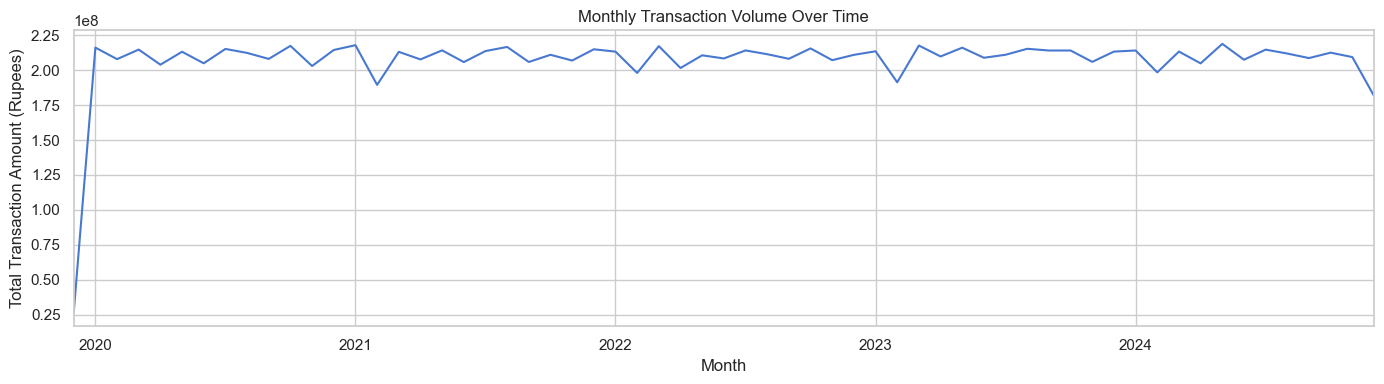

In [90]:
#Compare transaction amounts for overdue vs. non-overdue loans.
transactions['Txn_Month'] = transactions['Transaction_Date'].dt.to_period('M')
monthly_txn = transactions.groupby('Txn_Month')['Amount'].sum()

plt.figure(figsize=(14, 4))
monthly_txn.plot()
plt.title('Monthly Transaction Volume Over Time')
plt.ylabel('Total Transaction Amount (Rupees)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
